In [1]:
import json
import random
import re
from datetime import datetime

import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pystac_client
import requests
import seaborn
import seaborn as sns
import shapely
from helpers.comparison_helpers import *
from helpers.extraction_data_methods import *
from helpers.kfold import Kfold
from helpers.mlp_multiclass import *
from helpers.simplecube_helpers import *
from matplotlib.colors import LinearSegmentedColormap
from scipy.signal import savgol_filter
from scipy.spatial import cKDTree
from shapely import wkt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

path = "./dataset/samples"

In [2]:
year = 2024
tiles = ["C51L41", "C51L34", "C60L63"]
sources = ["alphaearth",  "tessera", "sentinel2"]
cores_classes = {
    "CORTE SELETIVO": "#FF694D",
    "VEGETACAO NATURAL FLORESTAL SECUNDARIA": "#00991A",
    "VEGETACAO NATURAL FLORESTAL PRIMARIA": "#70FF85",
    # --- CORTE SELETIVO ---
    "(C51L34) CORTE SELETIVO": "#C4280E",
    "(C51L41) CORTE SELETIVO": "#FF4500",
    "(C60L63) CORTE SELETIVO": "#FF9E8C",
    # --- VEGETAÇÃO NATURAL FLORESTAL SECUNDÁRIA ---
    "(C51L34) VEGETACAO NATURAL FLORESTAL SECUNDARIA": "#00520E",
    "(C51L41) VEGETACAO NATURAL FLORESTAL SECUNDARIA": "#00BD20",
    "(C60L63) VEGETACAO NATURAL FLORESTAL SECUNDARIA": "#4DE066",
    # --- VEGETAÇÃO NATURAL FLORESTAL PRIMÁRIA ---
    "(C51L34) VEGETACAO NATURAL FLORESTAL PRIMARIA": "#36D94E",
    "(C51L41) VEGETACAO NATURAL FLORESTAL PRIMARIA": "#9EFFAD",
    "(C60L63) VEGETACAO NATURAL FLORESTAL PRIMARIA": "#D1FFD7",
}

dataset = {"all": {}}

for src in sources:
    all_ = []
    for tile in tiles:
        df = None
        if src == "sentinel2":
            file_path = f"{path}/samples_{tile}_{year}_{src}_pixel.csv"
            df = read_gdf(file_path)
            df["tile"] = tile
        else:
            file_path = f"{path}/samples_{tile}_{year}_embeddings_{src}_pixel.csv"
            df = read_gdf(file_path)
        all_.append(df)
    dataset["all"][src] = pd.concat(all_, ignore_index=True)
    dataset["all"][src]["label_"] = "(" + dataset["all"][src]["tile"] + ") " + dataset["all"][src]["label"]

gdfs_alinhados = find_commom_geoms_nearest([
    dataset["all"]["alphaearth"],
    dataset["all"]["tessera"],
    dataset["all"]["sentinel2"]
], max_distance_meters=5)
dataset["all"]["alphaearth"] = gdfs_alinhados[0]
dataset["all"]["tessera"]    = gdfs_alinhados[1]
dataset["all"]["sentinel2"]  = gdfs_alinhados[2]

for tile in tiles:
    dataset[tile] = {}
    for src in sources:
        if src == "sentinel2":
            file_path = f"{path}/samples_{tile}_{year}_{src}_pixel.csv"
        else:
            file_path = f"{path}/samples_{tile}_{year}_embeddings_{src}_pixel.csv"
        dataset[tile][src] = read_gdf(file_path)
    gdfs_alinhados = find_commom_geoms_nearest([
        dataset[tile]["alphaearth"],
        dataset[tile]["tessera"],
        dataset[tile]["sentinel2"]
    ], max_distance_meters=5)
    dataset[tile]["alphaearth"] = gdfs_alinhados[0]
    dataset[tile]["tessera"]    = gdfs_alinhados[1]
    dataset[tile]["sentinel2"]  = gdfs_alinhados[2]

In [3]:
# tile = "all"
tile = tiles[0]
source = "sentinel2"
label_column = "label"

samples = dataset[tile][source].copy()

X = []
y = []

for _, row in samples.iterrows():
    X.append(extract_features(row["time_series"]))
    y.append(encode_label(samples, row["label"]))
    
X = np.array(X)
y = np.array(y)

# 2. Splits de treino, teste e validação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# 3. Estatísticas calculadas exclusivamente a partir de X_train
mean = X_train.mean(axis=0)
std = np.std(X_train, axis=0)
std[std == 0] = 1e-8  # Evita divisão por zero

# 4. Aplicação consistente da normalização z-score
X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

# # Quantidade de amostras
# train_size = len(X_train)
# val_size = len(X_val)
# test_size = len(X_test)

# sizes = [train_size, val_size, test_size]
# labels = [
#     f"Train ({train_size})",
#     f"Validation ({val_size})",
#     f"Test ({test_size})"
# ]
# plt.figure()
# plt.pie(
#     sizes,
#     labels=labels,
#     autopct='%1.1f%%',
#     startangle=90
# )
# plt.title("Dataset Split Proportions")
# plt.axis('equal')
# plt.show()

In [33]:
# tile = "all"
tile = tiles[0]
source = "alphaearth"
label_column = "label"

samples = dataset[tile][source].copy()

X = []
y = []

for _, row in samples.iterrows():
    X.append(extract_features(row))
    y.append(encode_label(samples, row["label"]))
    
X = np.array(X)
y = np.array(y)

# 2. Splits de treino, teste e validação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# 3. Estatísticas calculadas exclusivamente a partir de X_train
mean = X_train.mean(axis=0)
std = np.std(X_train, axis=0)
std[std == 0] = 1e-8  # Evita divisão por zero

# 4. Aplicação consistente da normalização z-score
X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

In [34]:
# tile = "all"
tile = tiles[0]
source = "tessera"
label_column = "label"

samples = dataset[tile][source].copy()

X = []
y = []

for _, row in samples.iterrows():
    X.append(extract_features(row))
    y.append(encode_label(samples, row["label"]))
    
X = np.array(X)
y = np.array(y)

# 2. Splits de treino, teste e validação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# 3. Estatísticas calculadas exclusivamente a partir de X_train
mean = X_train.mean(axis=0)
std = np.std(X_train, axis=0)
std[std == 0] = 1e-8  # Evita divisão por zero

# 4. Aplicação consistente da normalização z-score
X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

In [45]:
def get_arch_instance(input_size, num_classes, seed: int = 42):
    # 2. Topologia e Definição das Camadas
    topology = [input_size, 32, 16, num_classes]
    
    layers = [
        Layer(32, Neuron, relu, d_relu),
        Layer(16, Neuron, relu, d_relu),
        Layer(num_classes, Neuron, softmax, d_softmax, multiclass=True),
    ]
    
    # 3. Inicialização da Rede
    return FFNeuralNetwork(
        topology=topology,
        layers=layers,
        method_init=He_,
        multiclass=True,
        lambda_l2=1e-4,
        rand_seed=seed,
    )

Epoch 0 | Train Loss: 0.948659 | Val Loss: 0.724899
Epoch 50 | Train Loss: 0.140988 | Val Loss: 0.206029
Epoch 100 | Train Loss: 0.101916 | Val Loss: 0.188579
Epoch 150 | Train Loss: 0.079612 | Val Loss: 0.184264

Early stopping at epoch 165
Best validation loss: 0.184264


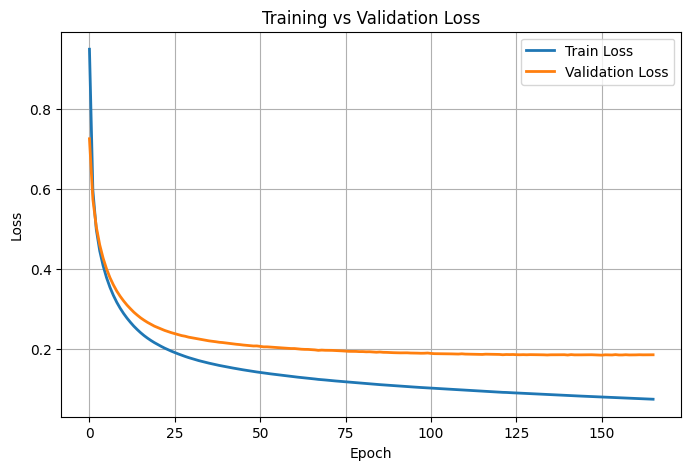

In [51]:
# 1. Dimensões dinâmicas de entrada e saída
input_size = X.shape[1]
num_classes = len(np.unique(y))  # Detecta automaticamente se são 3 ou 9 classes

model = get_arch_instance(input_size, num_classes)

# 4. Treinamento com Validação e Visualização
model.fit_with_validation(
    X_train,
    y_train,
    X_val,
    y_val,
    learning_rate=0.0001,
    n_epochs=200,
    patience=15,
)

model.plot_train_val_loss()

{'accuracy': 0.94214463840399, 'precision': 0.8912208428070164, 'recall': 0.8920119138013508, 'f1_score': 0.8916105694996173}


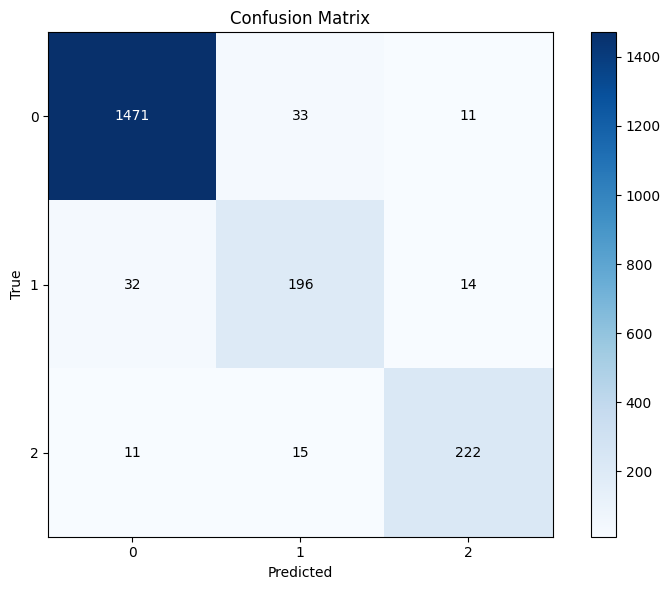

In [52]:
test_results = model.test(X_test, y_test, threshold=0.7)

print(test_results["metrics"])

# predictions
y_probs, y_preds = model.predict(X_test)

# plot confusion matrix
model.plot_confusion_matrix(y_test, y_preds)